# Mini-Challenge 2: Sentiment Analysis

This notebook presents the full Mini-Challenge 2 workflow in one place. It starts with agreement-aware data preparation, then covers baseline comparison, embedding-based weak labeling, semi-supervised retraining, a manual-label time-savings estimate, and an agreement-level comparison.

The implementation stays intentionally explicit in the notebook. Only `models.py` remains external for a small classifier wrapper and shared metric helpers.

In [1]:
import inspect
import os
from pathlib import Path
from typing import Dict, List

import torch

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["MPLCONFIGDIR"] = os.path.abspath(".matplotlib")
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

from IPython.display import Markdown, display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from datasets import Dataset, load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from transformers import (
    AutoModel,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    logging as transformers_logging,
    set_seed as hf_set_seed,
)

from models import (
    SentimentClassifier,
    compute_confusion_matrix,
    compute_metrics,
    get_device,
)

transformers_logging.set_verbosity_error()


In [2]:
def _find_local_phrasebank_dir() -> Path:
    """Locate a local Financial PhraseBank cache if HF loading is unavailable."""
    candidate_roots = [
        Path.cwd() / "FinancialPhraseBank-v1.0",
        Path.home() / ".cache" / "huggingface" / "datasets" / "downloads" / "extracted",
    ]

    for root in candidate_roots:
        if not root.exists():
            continue

        if (
            root.name == "FinancialPhraseBank-v1.0"
            and (root / "Sentences_AllAgree.txt").exists()
        ):
            return root

        for candidate in root.rglob("FinancialPhraseBank-v1.0"):
            if (candidate / "Sentences_AllAgree.txt").exists():
                return candidate

    raise FileNotFoundError(
        "Could not find a local FinancialPhraseBank-v1.0 directory. "
        "Download the dataset once with Hugging Face or place the raw files locally."
    )


def _load_phrasebank_subset(
    config_name: str,
    dataset_name: str = "takala/financial_phrasebank",
) -> pd.DataFrame:
    """Load one agreement subset with a local fallback."""
    label_map = {"negative": 0, "neutral": 1, "positive": 2}
    filename_map = {
        "sentences_allagree": "Sentences_AllAgree.txt",
        "sentences_75agree": "Sentences_75Agree.txt",
        "sentences_66agree": "Sentences_66Agree.txt",
        "sentences_50agree": "Sentences_50Agree.txt",
    }

    try:
        dataset_dir = _find_local_phrasebank_dir()
    except FileNotFoundError:
        dataset_dir = None

    if dataset_dir is not None:
        rows = []
        with open(
            dataset_dir / filename_map[config_name],
            encoding="iso-8859-1",
        ) as handle:
            for line in handle:
                sentence, label = line.rsplit("@", 1)
                rows.append(
                    {
                        "sentence": sentence,
                        "label": label_map[label.strip()],
                    }
                )
        df = pd.DataFrame(rows)
    else:
        dataset = load_dataset(dataset_name, config_name, split="train")
        df = dataset.to_pandas()[["sentence", "label"]].copy()
        if df["label"].dtype == object:
            df["label"] = df["label"].map(label_map)

    df["agreement_subset"] = config_name
    return df


def _deduplicate_sentences(df: pd.DataFrame, subset_name: str) -> pd.DataFrame:
    """Drop duplicate sentences and keep the first occurrence."""
    duplicate_rows = df[df.duplicated(subset=["sentence"], keep=False)]
    if not duplicate_rows.empty:
        conflicting_duplicates = (
            duplicate_rows.groupby("sentence")["label"].nunique().gt(1).sum()
        )
        deduped = df.drop_duplicates(subset=["sentence"], keep="first").copy()
        removed_rows = len(df) - len(deduped)
        print(
            f"{subset_name}: removed {removed_rows} duplicate rows "
            f"across {duplicate_rows['sentence'].nunique()} duplicated sentences "
            f"({conflicting_duplicates} conflicting-label cases resolved by "
            "first occurrence)."
        )
        return deduped.reset_index(drop=True)

    return df.reset_index(drop=True)


def _attach_example_ids(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    result = df.copy().reset_index(drop=True)
    result.index = [f"{prefix}_{idx:05d}" for idx in range(len(result))]
    result.index.name = "example_id"
    return result


def load_agreement_aware_splits(
    dataset_name: str = "takala/financial_phrasebank",
    seed: int = 42,
    test_size: float = 0.2,
    val_size: float = 0.1,
    train_sizes: List[int] = [100, 250, 500, 1000],
) -> Dict[str, pd.DataFrame]:
    """Create clean train/validation/test splits with agreement awareness."""
    if train_sizes != sorted(train_sizes):
        raise ValueError("train_sizes must be sorted in ascending order.")

    max_train_size = max(train_sizes)

    print("Loading Financial PhraseBank agreement subsets...")
    allagree_df = _deduplicate_sentences(
        _load_phrasebank_subset("sentences_allagree", dataset_name),
        subset_name="100% agreement subset",
    )
    allagree_df = _attach_example_ids(allagree_df, prefix="allagree")

    non100_frames = []
    for config_name in ["sentences_75agree", "sentences_66agree", "sentences_50agree"]:
        subset_df = _load_phrasebank_subset(config_name, dataset_name)
        non100_frames.append(subset_df)

    combined_non100_df = pd.concat(non100_frames, ignore_index=True)
    combined_non100_df = combined_non100_df[
        ~combined_non100_df["sentence"].isin(set(allagree_df["sentence"]))
    ].copy()
    combined_non100_df = _deduplicate_sentences(
        combined_non100_df,
        subset_name="Combined non-100% agreement pool",
    )
    combined_non100_df = _attach_example_ids(combined_non100_df, prefix="disagree")

    remaining_allagree_df, test_allagree_df = train_test_split(
        allagree_df,
        test_size=test_size,
        random_state=seed,
        stratify=allagree_df["label"],
    )
    remaining_disagree_df, test_disagree_df = train_test_split(
        combined_non100_df,
        test_size=test_size,
        random_state=seed,
        stratify=combined_non100_df["label"],
    )

    train_hidden_allagree_df, val_allagree_df = train_test_split(
        remaining_allagree_df,
        test_size=val_size,
        random_state=seed,
        stratify=remaining_allagree_df["label"],
    )

    if len(train_hidden_allagree_df) <= max_train_size:
        raise ValueError(
            "Not enough 100%-agreement data left after test/val splits to support "
            f"max training size {max_train_size}."
        )

    shuffled_clean_pool = train_hidden_allagree_df.sample(frac=1, random_state=seed)
    hard_label_train_pool = shuffled_clean_pool.iloc[:max_train_size].copy()
    hidden_allagree_pool = shuffled_clean_pool.iloc[max_train_size:].copy()

    if hidden_allagree_pool.empty:
        raise ValueError(
            "hidden_allagree_pool is empty; adjust split sizes or train_sizes."
        )

    splits = {
        "allagree_full": allagree_df,
        "combined_non100_pool": combined_non100_df,
        "remaining_disagree_pool": remaining_disagree_df.copy(),
        "test_allagree": test_allagree_df.copy(),
        "test_disagree": test_disagree_df.copy(),
        "val_allagree": val_allagree_df.copy(),
        "hard_label_train_pool": hard_label_train_pool.copy(),
        "hidden_allagree_pool": hidden_allagree_pool.copy(),
    }

    for size in train_sizes:
        if size > len(hard_label_train_pool):
            raise ValueError(
                "Requested train size "
                f"{size} exceeds available hard-label pool "
                f"{len(hard_label_train_pool)}."
            )
        splits[f"train_{size}"] = hard_label_train_pool.iloc[:size].copy()

    print("\nAgreement-aware split sizes:")
    for key in [
        "allagree_full",
        "combined_non100_pool",
        "test_allagree",
        "test_disagree",
        "val_allagree",
        "hard_label_train_pool",
        "hidden_allagree_pool",
    ]:
        print(f"  {key}: {len(splits[key])}")
    for size in train_sizes:
        print(f"  train_{size}: {len(splits[f'train_{size}'])}")

    return splits

# Data Preparation

This notebook now treats **Financial PhraseBank** as an agreement-aware dataset rather than a single flat corpus. We load the four published agreement subsets separately, deduplicate repeated sentences, and keep the overall workflow inside the notebook.

For hard-label training we use only the deduplicated **100% agreement** subset. This keeps the seed training data as clean as possible before any weak-labeling step is introduced.

We also keep **two frozen test sets**:
- `test_allagree` measures performance on the cleanest labels.
- `test_disagree` measures robustness on sentences that required weaker annotator agreement.

The **hidden clean pool** also comes from originally labeled 100%-agreement data. Later weak-labeling experiments can therefore treat it as unlabeled during training while we still retain trustworthy ground truth for offline evaluation.

## Load Agreement-Aware Data and Create Frozen Splits

We use the `load_agreement_aware_splits` helper defined above.

Method summary:
- Load `sentences_allagree`, `sentences_75agree`, `sentences_66agree`, and `sentences_50agree` separately.
- Use only deduplicated 100%-agreement data for `train_*`, `val_allagree`, and `hidden_allagree_pool`.
- Build a combined non-100%-agreement pool from the remaining subsets, removing duplicates while keeping higher-agreement rows first.
- Freeze `test_allagree` and `test_disagree` once and reuse them for every later experiment.
- Keep `hidden_allagree_pool` constant for every train size so comparisons stay methodologically aligned.

In [3]:
splits = load_agreement_aware_splits()
train_sizes = [100, 250, 500, 1000]

test_allagree_df = splits["test_allagree"]
test_disagree_df = splits["test_disagree"]
val_allagree_df = splits["val_allagree"]
hidden_allagree_pool = splits["hidden_allagree_pool"]

SENTIMENT_ID2LABEL = {
    0: "negative",
    1: "neutral",
    2: "positive",
}
SENTIMENT_LABEL2ID = {
    label_name: label_id for label_id, label_name in SENTIMENT_ID2LABEL.items()
}
NEGATIVE_LABEL = 0

BASELINE_MODEL_NAMES = {
    "distilbert": "distilbert-base-uncased",
    "modernbert": "answerdotai/ModernBERT-base",
}
BASELINE_COMPARISON_TRAIN_SIZE = max(train_sizes)


def prepare_text_dataset(df, tokenizer, text_column="sentence", label_column="label"):
    keep_columns = [text_column]
    if label_column in df.columns:
        keep_columns.append(label_column)

    dataset = Dataset.from_pandas(
        df[keep_columns].reset_index(drop=True),
        preserve_index=False,
    )

    def tokenize_batch(batch):
        return tokenizer(batch[text_column], truncation=True)

    return dataset.map(tokenize_batch, batched=True, remove_columns=[text_column])



def create_training_args(
    output_dir,
    batch_size=16,
    epochs=3,
    learning_rate=2e-5,
    seed=42,
):
    device = get_device()
    hf_set_seed(seed)

    training_kwargs = {
        "output_dir": output_dir,
        "eval_strategy": "epoch",
        "save_strategy": "epoch",
        "learning_rate": learning_rate,
        "per_device_train_batch_size": batch_size,
        "per_device_eval_batch_size": batch_size,
        "num_train_epochs": epochs,
        "weight_decay": 0.01,
        "load_best_model_at_end": True,
        "metric_for_best_model": "eval_negative_f1",
        "greater_is_better": True,
        "logging_dir": f"{output_dir}/logs",
        "logging_steps": 10,
        "report_to": "none",
        "seed": seed,
        "data_seed": seed,
        "dataloader_num_workers": 0,
        "dataloader_pin_memory": device.type == "cuda",
    }

    signature = inspect.signature(TrainingArguments.__init__)
    if "use_mps_device" in signature.parameters:
        training_kwargs["use_mps_device"] = device.type == "mps"
    if "use_cpu" in signature.parameters:
        training_kwargs["use_cpu"] = device.type == "cpu"
    elif "no_cuda" in signature.parameters:
        training_kwargs["no_cuda"] = device.type == "cpu"

    return TrainingArguments(**training_kwargs)


print("Available split keys:")
for key in splits:
    print(f"  {key}")

print("\nBaseline backbones to compare:")
for key, model_name in BASELINE_MODEL_NAMES.items():
    print(f"  {key}: {model_name}")
print(f"\nLearning-curve train sizes: {train_sizes}")
print("Frozen evaluation splits: val_allagree, test_allagree, test_disagree")
print(f"Hidden clean pool size: {len(hidden_allagree_pool)}")


Loading Financial PhraseBank agreement subsets...
100% agreement subset: removed 5 duplicate rows across 5 duplicated sentences (0 conflicting-label cases resolved by first occurrence).
Combined non-100% agreement pool: removed 3145 duplicate rows across 1952 duplicated sentences (2 conflicting-label cases resolved by first occurrence).

Agreement-aware split sizes:
  allagree_full: 2259
  combined_non100_pool: 2579
  test_allagree: 452
  test_disagree: 516
  val_allagree: 181
  hard_label_train_pool: 1000
  hidden_allagree_pool: 626
  train_100: 100
  train_250: 250
  train_500: 500
  train_1000: 1000
Available split keys:
  allagree_full
  combined_non100_pool
  remaining_disagree_pool
  test_allagree
  test_disagree
  val_allagree
  hard_label_train_pool
  hidden_allagree_pool
  train_100
  train_250
  train_500
  train_1000

Baseline backbones to compare:
  distilbert: distilbert-base-uncased
  modernbert: answerdotai/ModernBERT-base

Learning-curve train sizes: [100, 250, 500, 100

## Sanity Checks

Verify the nested hard-label training property, enforce split separation, and inspect class distributions for both frozen test sets.

In [4]:
train_100 = splits["train_100"]
train_250 = splits["train_250"]
train_500 = splits["train_500"]
train_1000 = splits["train_1000"]

assert set(train_100.index).issubset(set(train_250.index))
assert set(train_250.index).issubset(set(train_500.index))
assert set(train_500.index).issubset(set(train_1000.index))


def assert_no_sentence_overlap(
    name_a: str,
    df_a: pd.DataFrame,
    name_b: str,
    df_b: pd.DataFrame,
) -> None:
    overlap = set(df_a["sentence"]) & set(df_b["sentence"])
    assert not overlap, (
        f"Overlap detected between {name_a} and {name_b}: "
        f"{len(overlap)} shared sentences"
    )


held_out_groups = [
    ("val_allagree", splits["val_allagree"]),
    ("test_allagree", splits["test_allagree"]),
    ("test_disagree", splits["test_disagree"]),
    ("hidden_allagree_pool", splits["hidden_allagree_pool"]),
]

for train_name in ["train_100", "train_250", "train_500", "train_1000"]:
    for held_out_name, held_out_df in held_out_groups:
        assert_no_sentence_overlap(
            train_name,
            splits[train_name],
            held_out_name,
            held_out_df,
        )

for idx, (name_a, df_a) in enumerate(held_out_groups):
    for name_b, df_b in held_out_groups[idx + 1 :]:
        assert_no_sentence_overlap(name_a, df_a, name_b, df_b)

label_names = {0: "negative", 1: "neutral", 2: "positive"}


def label_distribution(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    counts = df["label"].value_counts().sort_index().rename(index=label_names)
    proportions = (
        df["label"]
        .value_counts(normalize=True)
        .sort_index()
        .rename(index=label_names)
    )
    return pd.DataFrame(
        {
            f"{split_name}_count": counts,
            f"{split_name}_share": proportions.round(3),
        }
    )


distribution_summary = pd.concat(
    [
        label_distribution(splits["test_allagree"], "test_allagree"),
        label_distribution(splits["test_disagree"], "test_disagree"),
    ],
    axis=1,
).fillna(0)

print("Hierarchical property verified.")
print("No overlap detected between train / val / test / hidden splits.")
display(distribution_summary)

Hierarchical property verified.
No overlap detected between train / val / test / hidden splits.


,test_allagree_count,test_allagree_share,test_disagree_count,test_disagree_share
label,,,,
negative,61,0.135,60,0.116
neutral,277,0.613,297,0.576
positive,114,0.252,159,0.308


## Visualize Hard-Label Train Distribution

These plots show the label distribution of the nested hard-label training splits drawn only from the 100%-agreement subset.

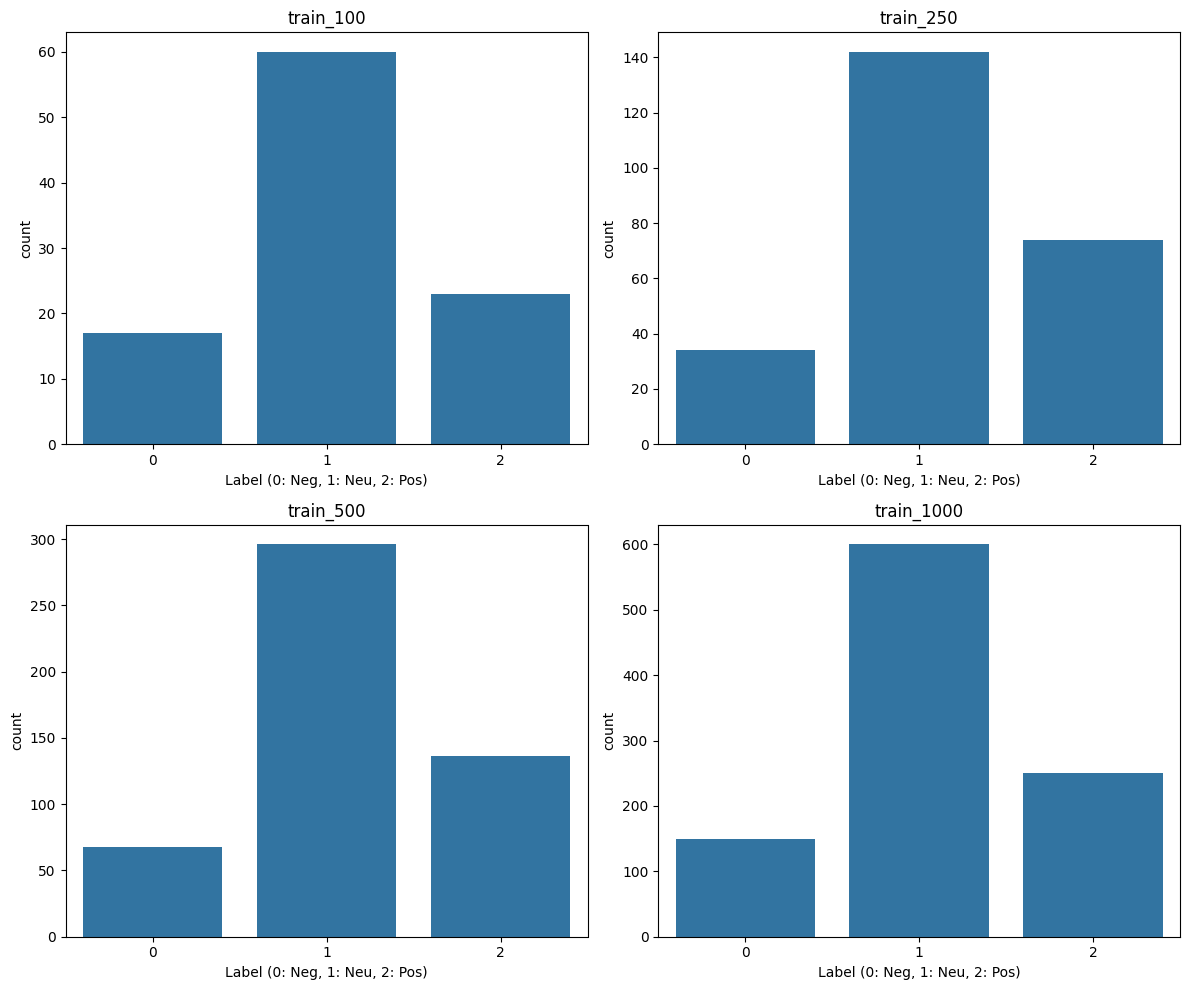

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, size in enumerate(train_sizes):
    train_df = splits[f"train_{size}"]
    sns.countplot(x="label", data=train_df, ax=axes[i])
    axes[i].set_title(f"train_{size}")
    axes[i].set_xlabel("Label (0: Neg, 1: Neu, 2: Pos)")

plt.tight_layout()
plt.show()

## Data Preparation Summary

The setup above fixes the evaluation protocol for the rest of the notebook:
- `train_100`, `train_250`, `train_500`, and `train_1000` are nested clean seed sets from the 100%-agreement subset.
- `val_allagree`, `test_allagree`, and `test_disagree` stay frozen across all later experiments.
- `hidden_allagree_pool` is treated as unlabeled during weak-label generation but still has clean labels for offline evaluation.

With the data split fixed, the next step is a direct supervised baseline comparison before any weak labels are introduced.

# Baseline Comparison

The first experiment block compares two classifier backbones under the same train sizes, validation split, and evaluation protocol:
- DistilBERT: `distilbert-base-uncased`
- ModernBERT: `answerdotai/ModernBERT-base`

This establishes the supervised reference point for everything that follows.

## Baseline Setup

Both backbones use the same split definitions, metric function, and training arguments so the comparison stays transparent and easy to explain.

## Build Baseline Learning Curves for Both Classifier Models

For this step, we extend the baseline comparison into a simple nested loop over both classifier backbones and all four hard-label training sizes.

Each run is evaluated on `val_allagree`, `test_allagree`, and `test_disagree` so we can compare scaling behavior on the clean and disagreement-aware test sets.

In [6]:
baseline_eval_splits = {
    "val_allagree": val_allagree_df,
    "test_allagree": test_allagree_df,
    "test_disagree": test_disagree_df,
}

baseline_results = []
baseline_train_sizes = train_sizes

for baseline_model_key, baseline_model_name in BASELINE_MODEL_NAMES.items():
    print(
        f"\n=== Baseline learning curve: {baseline_model_key} "
        f"({baseline_model_name}) ==="
    )

    for baseline_train_size in baseline_train_sizes:
        print(f"Training {baseline_model_key} on train_{baseline_train_size}")
        baseline_train_df = splits[f"train_{baseline_train_size}"]

        baseline_classifier = SentimentClassifier(
            model_name=baseline_model_name,
            num_labels=len(SENTIMENT_ID2LABEL),
        )
        baseline_classifier.set_label_mapping(SENTIMENT_ID2LABEL, SENTIMENT_LABEL2ID)

        train_dataset = prepare_text_dataset(
            baseline_train_df,
            baseline_classifier.tokenizer,
        )
        val_dataset = prepare_text_dataset(
            val_allagree_df,
            baseline_classifier.tokenizer,
        )
        data_collator = DataCollatorWithPadding(tokenizer=baseline_classifier.tokenizer)

        baseline_trainer = Trainer(
            model=baseline_classifier.model,
            args=create_training_args(
                output_dir=f"models/{baseline_model_key}_{baseline_train_size}",
                batch_size=16,
                epochs=3,
                seed=42,
            ),
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            data_collator=data_collator,
            compute_metrics=lambda eval_pred: compute_metrics(
                eval_pred,
                negative_label=NEGATIVE_LABEL,
            ),
        )

        baseline_trainer.train()

        for evaluation_split_name, evaluation_split_df in baseline_eval_splits.items():
            evaluation_dataset = prepare_text_dataset(
                evaluation_split_df,
                baseline_classifier.tokenizer,
            )
            evaluation_predictions = baseline_trainer.predict(evaluation_dataset)
            evaluation_metrics = compute_metrics(
                (evaluation_predictions.predictions, evaluation_predictions.label_ids),
                negative_label=NEGATIVE_LABEL,
            )

            baseline_results.append(
                {
                    "model_key": baseline_model_key,
                    "model_name": baseline_model_name,
                    "train_size": baseline_train_size,
                    "evaluation_split": evaluation_split_name,
                    **evaluation_metrics,
                }
            )

print(f"Collected {len(baseline_results)} baseline evaluation rows.")



=== Baseline learning curve: distilbert (distilbert-base-uncased) ===
Training distilbert on train_100


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/181 [00:00<?, ? examples/s]

{'eval_loss': '0.9895', 'eval_accuracy': '0.6133', 'eval_macro_f1': '0.2534', 'eval_negative_precision': '0', 'eval_negative_recall': '0', 'eval_negative_f1': '0', 'eval_runtime': '0.4451', 'eval_samples_per_second': '406.6', 'eval_steps_per_second': '26.96', 'epoch': '1'}


...

{'train_runtime': '42.95', 'train_samples_per_second': '69.85', 'train_steps_per_second': '4.4', 'train_loss': '0.2735', 'epoch': '3'}


Map:   0%|          | 0/181 [00:00<?, ? examples/s]

Map:   0%|          | 0/452 [00:00<?, ? examples/s]

Map:   0%|          | 0/516 [00:00<?, ? examples/s]

Collected 24 baseline evaluation rows.


## Baseline Comparison Results

The table and learning-curve plots below summarize how the two supervised backbones behave as the number of manually labeled examples increases.

In [7]:
baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df = baseline_results_df[
    [
        "model_key",
        "model_name",
        "train_size",
        "evaluation_split",
        "negative_f1",
        "accuracy",
        "macro_f1",
        "negative_precision",
        "negative_recall",
    ]
].sort_values(
    ["evaluation_split", "model_key", "train_size"],
    ascending=[True, True, True],
).reset_index(drop=True)

display(
    baseline_results_df.style.format(
        {
            "negative_f1": "{:.4f}",
            "accuracy": "{:.4f}",
            "macro_f1": "{:.4f}",
            "negative_precision": "{:.4f}",
            "negative_recall": "{:.4f}",
        }
    ).background_gradient(subset=["negative_f1"], cmap="YlGn")
)

,model_key,model_name,train_size,evaluation_split,negative_f1,accuracy,macro_f1,negative_precision,negative_recall
0,distilbert,distilbert-base-uncased,100,test_allagree,0.0000,0.6128,0.2533,0.0000,0.0000
1,distilbert,distilbert-base-uncased,250,test_allagree,0.0000,0.7035,0.4384,0.0000,0.0000
2,distilbert,distilbert-base-uncased,500,test_allagree,0.0000,0.7500,0.4995,0.0000,0.0000
3,distilbert,distilbert-base-uncased,1000,test_allagree,0.8852,0.9336,0.9106,0.8852,0.8852
4,modernbert,answerdotai/ModernBERT-base,100,test_allagree,0.0800,0.7456,0.5186,0.2143,0.0492
5,modernbert,answerdotai/ModernBERT-base,250,test_allagree,0.5273,0.7699,0.6755,0.5918,0.4754
6,modernbert,answerdotai/ModernBERT-base,500,test_allagree,0.5686,0.8252,0.7261,0.7073,0.4754
7,modernbert,answerdotai/ModernBERT-base,1000,test_allagree,0.9524,0.9580,0.9479,0.9231,0.9836
8,distilbert,distilbert-base-uncased,100,test_disagree,0.0000,0.5756,0.2435,0.0000,0.0000
9,distilbert,distilbert-base-uncased,250,test_disagree,0.0000,0.5775,0.2547,0.0000,0.0000


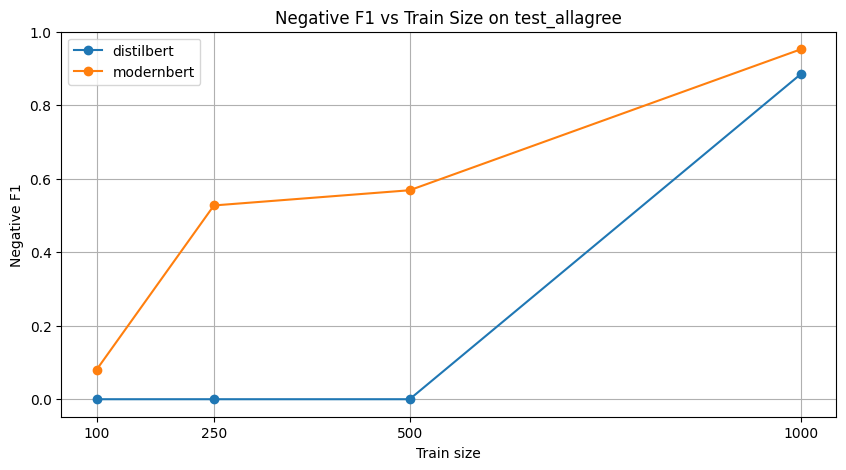

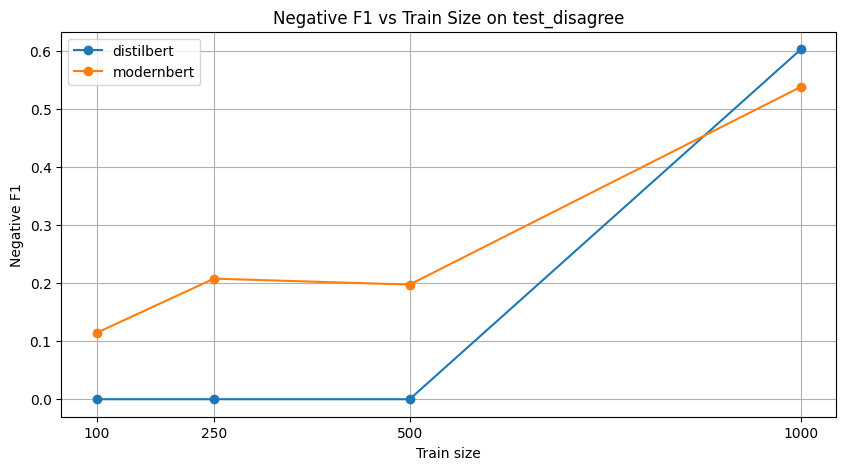

In [8]:
test_allagree_results_df = baseline_results_df[
    baseline_results_df["evaluation_split"] == "test_allagree"
]
test_disagree_results_df = baseline_results_df[
    baseline_results_df["evaluation_split"] == "test_disagree"
]

plt.figure(figsize=(10, 5))
for baseline_model_key in BASELINE_MODEL_NAMES:
    model_results_df = test_allagree_results_df[
        test_allagree_results_df["model_key"] == baseline_model_key
    ]
    plt.plot(
        model_results_df["train_size"],
        model_results_df["negative_f1"],
        marker="o",
        label=baseline_model_key,
    )

plt.title("Negative F1 vs Train Size on test_allagree")
plt.xlabel("Train size")
plt.ylabel("Negative F1")
plt.xticks(baseline_train_sizes)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
for baseline_model_key in BASELINE_MODEL_NAMES:
    model_results_df = test_disagree_results_df[
        test_disagree_results_df["model_key"] == baseline_model_key
    ]
    plt.plot(
        model_results_df["train_size"],
        model_results_df["negative_f1"],
        marker="o",
        label=baseline_model_key,
    )

plt.title("Negative F1 vs Train Size on test_disagree")
plt.xlabel("Train size")
plt.ylabel("Negative F1")
plt.xticks(baseline_train_sizes)
plt.legend()
plt.grid(True)
plt.show()

## Baseline Comparison Interpretation

This section answers two baseline questions for the assignment:
- which classifier backbone gives the stronger supervised reference point
- how large the gap remains between `test_allagree` and `test_disagree`

The semi-supervised section below keeps this decision simple by reusing the backbone with the strongest `negative_f1` on `val_allagree` at the largest train size.

# Weak Labeling

With the supervised baseline established, the next question is whether a small clean seed set can generate useful additional labels. This section first compares embedding spaces, then uses the stronger embedding setup for simple k-NN weak labeling.

## Embedding Models and Scope

For the weak-labeling step we compare:
- `sentence-transformers/all-MiniLM-L6-v2` as the SBERT-style sentence embedding model
- `bert-base-uncased` as a plain BERT baseline with simple mean pooling over token embeddings

The seed data comes from the clean hard-label pool, and the agreement-level effect of noisier seed labels is tested later in its own matched comparison section.

In [9]:
SBERT_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
BERT_MODEL_NAME = "bert-base-uncased"
EMBEDDING_BATCH_SIZE = 32

print("SBERT model:", SBERT_MODEL_NAME)
print("Plain BERT model:", BERT_MODEL_NAME)
print("Embedding batch size:", EMBEDDING_BATCH_SIZE)


SBERT model: sentence-transformers/all-MiniLM-L6-v2
Plain BERT model: bert-base-uncased
Embedding batch size: 32


## Load Embedding Models

The loading code stays explicit so the embedding choices and pooling rule remain visible in the notebook.

In [10]:
embedding_device = get_device()

sbert_model = SentenceTransformer(
    SBERT_MODEL_NAME,
    device=str(embedding_device),
)

bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME, use_fast=True)
bert_model = AutoModel.from_pretrained(BERT_MODEL_NAME)
bert_model.to(embedding_device)
bert_model.eval()


def encode_with_plain_bert(sentences, batch_size=EMBEDDING_BATCH_SIZE):
    """Plain BERT baseline: mean-pool token embeddings with the attention mask."""
    pooled_batches = []

    for start in range(0, len(sentences), batch_size):
        batch_sentences = sentences[start : start + batch_size]
        batch = bert_tokenizer(
            batch_sentences,
            padding=True,
            truncation=True,
            return_tensors="pt",
        )
        batch = {
            name: tensor.to(embedding_device)
            for name, tensor in batch.items()
        }

        with torch.no_grad():
            outputs = bert_model(**batch)

        token_embeddings = outputs.last_hidden_state
        attention_mask = batch["attention_mask"].unsqueeze(-1)
        summed_embeddings = (token_embeddings * attention_mask).sum(dim=1)
        token_counts = attention_mask.sum(dim=1).clamp(min=1)
        pooled_embeddings = summed_embeddings / token_counts
        pooled_batches.append(pooled_embeddings.cpu().numpy())

    return np.vstack(pooled_batches)


print("Embedding device:", embedding_device)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Embedding device: mps


## Build Embeddings for the Seed Set and Hidden Pool

We embed the full clean hard-label pool once so later cells can slice the nested seed sets directly from the same embedding arrays.

In [11]:
embedding_train_df = splits["hard_label_train_pool"].copy()
embedding_hidden_df = splits["hidden_allagree_pool"].copy()

embedding_train_texts = embedding_train_df["sentence"].tolist()
embedding_train_labels = embedding_train_df["label"].to_numpy()
embedding_hidden_texts = embedding_hidden_df["sentence"].tolist()
embedding_hidden_labels = embedding_hidden_df["label"].to_numpy()

embedding_counts_df = pd.DataFrame(
    [
        {
            "split": "hard_label_train_pool",
            "rows": len(embedding_train_df),
            "label_source": "observed hard labels",
        },
        {
            "split": "hidden_allagree_pool",
            "rows": len(embedding_hidden_df),
            "label_source": "hidden clean labels for later offline checks",
        },
    ]
)

display(embedding_counts_df)


,split,rows,label_source
0,hard_label_train_pool,1000,observed hard labels
1,hidden_allagree_pool,626,hidden clean labels for later offline checks


In [12]:
sbert_train_embeddings = sbert_model.encode(
    embedding_train_texts,
    batch_size=EMBEDDING_BATCH_SIZE,
    show_progress_bar=True,
)

sbert_hidden_embeddings = sbert_model.encode(
    embedding_hidden_texts,
    batch_size=EMBEDDING_BATCH_SIZE,
    show_progress_bar=True,
)

print("sbert_train_embeddings shape:", sbert_train_embeddings.shape)
print("sbert_hidden_embeddings shape:", sbert_hidden_embeddings.shape)


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Batches:   0%|          | 0/20 [00:00<?, ?it/s]

sbert_train_embeddings shape: (1000, 384)
sbert_hidden_embeddings shape: (626, 384)


In [13]:
bert_train_embeddings = encode_with_plain_bert(embedding_train_texts)
bert_hidden_embeddings = encode_with_plain_bert(embedding_hidden_texts)

print("bert_train_embeddings shape:", bert_train_embeddings.shape)
print("bert_hidden_embeddings shape:", bert_hidden_embeddings.shape)


bert_train_embeddings shape: (1000, 768)
bert_hidden_embeddings shape: (626, 768)


In [14]:
embedding_shapes_df = pd.DataFrame(
    [
        {
            "model": "SBERT",
            "model_name": SBERT_MODEL_NAME,
            "train_shape": tuple(sbert_train_embeddings.shape),
            "hidden_shape": tuple(sbert_hidden_embeddings.shape),
        },
        {
            "model": "BERT mean pool",
            "model_name": BERT_MODEL_NAME,
            "train_shape": tuple(bert_train_embeddings.shape),
            "hidden_shape": tuple(bert_hidden_embeddings.shape),
        },
    ]
)

display(embedding_shapes_df)

train_embedding_positions_by_size = {
    size: embedding_train_df.index.get_indexer(splits[f"train_{size}"].index)
    for size in train_sizes
}

sbert_train_embeddings_by_size = {
    size: sbert_train_embeddings[positions]
    for size, positions in train_embedding_positions_by_size.items()
}
bert_train_embeddings_by_size = {
    size: bert_train_embeddings[positions]
    for size, positions in train_embedding_positions_by_size.items()
}
train_texts_by_size = {
    size: splits[f"train_{size}"]["sentence"].tolist()
    for size in train_sizes
}
train_labels_by_size = {
    size: splits[f"train_{size}"]["label"].to_numpy()
    for size in train_sizes
}

embedding_artifacts = {
    "train_df": embedding_train_df,
    "hidden_df": embedding_hidden_df,
    "train_texts": embedding_train_texts,
    "train_labels": embedding_train_labels,
    "hidden_texts": embedding_hidden_texts,
    "hidden_labels": embedding_hidden_labels,
    "train_positions_by_size": train_embedding_positions_by_size,
    "train_texts_by_size": train_texts_by_size,
    "train_labels_by_size": train_labels_by_size,
    "sbert": {
        "model_name": SBERT_MODEL_NAME,
        "train_embeddings": sbert_train_embeddings,
        "hidden_embeddings": sbert_hidden_embeddings,
        "train_embeddings_by_size": sbert_train_embeddings_by_size,
    },
    "bert": {
        "model_name": BERT_MODEL_NAME,
        "train_embeddings": bert_train_embeddings,
        "hidden_embeddings": bert_hidden_embeddings,
        "train_embeddings_by_size": bert_train_embeddings_by_size,
    },
}


,model,model_name,train_shape,hidden_shape
0,SBERT,sentence-transformers/all-MiniLM-L6-v2,"(1000, 384)","(626, 384)"
1,BERT mean pool,bert-base-uncased,"(1000, 768)","(626, 768)"


## Simple Embedding Diagnostics

Before building k-NN weak labels, we compare the two embedding spaces on the hard-labeled seed pool with simple cosine-based checks:
- mean intra-class cosine similarity
- mean inter-class cosine similarity
- leave-one-out 1-nearest-neighbor label purity
- class-centroid cosine similarity

If SBERT gives cleaner local neighborhoods and a larger same-label versus different-label gap, that is a good sign for the later k-NN weak-labeling step.


,model,mean_intra_class_cosine,mean_inter_class_cosine,similarity_gap,leave_one_out_1nn_purity
0,SBERT,0.159,0.158,0.001,0.775
1,BERT mean pool,0.641,0.654,-0.013,0.778



SBERT centroid cosine similarity


,negative,neutral,positive
negative,1.000,0.615,0.862
neutral,0.615,1.000,0.759
positive,0.862,0.759,1.000



BERT mean pool centroid cosine similarity


,negative,neutral,positive
negative,1.000,0.928,0.991
neutral,0.928,1.000,0.947
positive,0.991,0.947,1.000


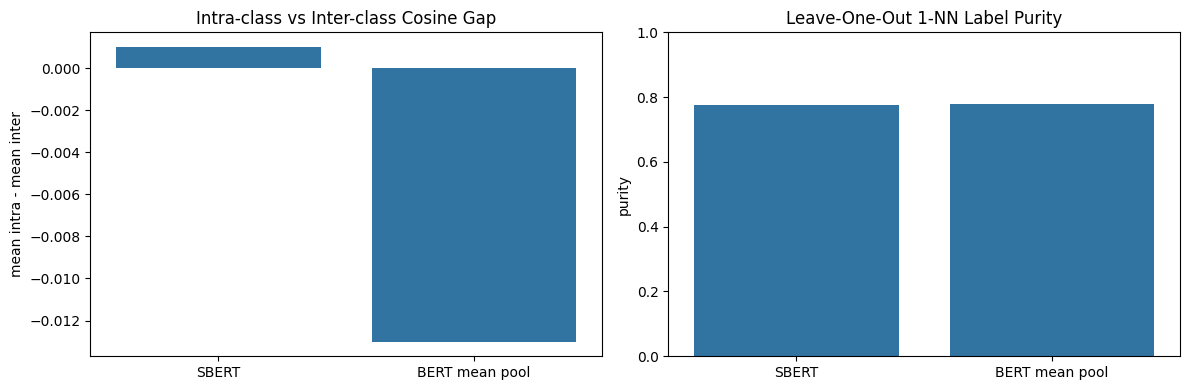

In [15]:
embedding_sets = {
    "SBERT": sbert_train_embeddings,
    "BERT mean pool": bert_train_embeddings,
}

similarity_rows = []
nn_rows = []
centroid_similarity_tables = {}

for model_label, embeddings in embedding_sets.items():
    normalized_embeddings = embeddings / np.clip(
        np.linalg.norm(embeddings, axis=1, keepdims=True),
        a_min=1e-12,
        a_max=None,
    )

    cosine_matrix = normalized_embeddings @ normalized_embeddings.T
    same_label_mask = (
        embedding_train_labels[:, None] == embedding_train_labels[None, :]
    )
    diagonal_mask = np.eye(len(embedding_train_labels), dtype=bool)

    intra_class_values = cosine_matrix[same_label_mask & ~diagonal_mask]
    inter_class_values = cosine_matrix[~same_label_mask]

    similarity_rows.append(
        {
            "model": model_label,
            "mean_intra_class_cosine": intra_class_values.mean(),
            "mean_inter_class_cosine": inter_class_values.mean(),
            "similarity_gap": intra_class_values.mean() - inter_class_values.mean(),
        }
    )

    leave_one_out_matrix = cosine_matrix.copy()
    np.fill_diagonal(leave_one_out_matrix, -np.inf)
    nearest_neighbor_indices = leave_one_out_matrix.argmax(axis=1)
    nearest_neighbor_labels = embedding_train_labels[nearest_neighbor_indices]
    nn_rows.append(
        {
            "model": model_label,
            "leave_one_out_1nn_purity": (
                nearest_neighbor_labels == embedding_train_labels
            ).mean(),
        }
    )

    centroid_vectors = {}
    centroid_order = [SENTIMENT_ID2LABEL[label_id] for label_id in sorted(SENTIMENT_ID2LABEL)]
    for label_id, label_name in SENTIMENT_ID2LABEL.items():
        class_embeddings = normalized_embeddings[embedding_train_labels == label_id]
        centroid = class_embeddings.mean(axis=0)
        centroid = centroid / np.clip(np.linalg.norm(centroid), a_min=1e-12, a_max=None)
        centroid_vectors[label_name] = centroid

    centroid_table = pd.DataFrame(index=centroid_order, columns=centroid_order, dtype=float)
    for row_label in centroid_order:
        for col_label in centroid_order:
            centroid_table.loc[row_label, col_label] = float(
                centroid_vectors[row_label] @ centroid_vectors[col_label]
            )
    centroid_similarity_tables[model_label] = centroid_table.round(3)

embedding_similarity_df = pd.DataFrame(similarity_rows).round(3)
embedding_nn_purity_df = pd.DataFrame(nn_rows).round(3)
embedding_quality_df = embedding_similarity_df.merge(embedding_nn_purity_df, on="model")

display(embedding_quality_df)

for model_label, centroid_table in centroid_similarity_tables.items():
    print(f"\n{model_label} centroid cosine similarity")
    display(centroid_table)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    data=embedding_quality_df,
    x="model",
    y="similarity_gap",
    ax=axes[0],
)
axes[0].set_title("Intra-class vs Inter-class Cosine Gap")
axes[0].set_ylabel("mean intra - mean inter")
axes[0].set_xlabel("")

sns.barplot(
    data=embedding_quality_df,
    x="model",
    y="leave_one_out_1nn_purity",
    ax=axes[1],
)
axes[1].set_title("Leave-One-Out 1-NN Label Purity")
axes[1].set_ylabel("purity")
axes[1].set_xlabel("")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


## k-NN Weak Label Generation

We now test direct weak-label generation on `hidden_allagree_pool` using the largest clean seed split first.

For this comparison we:
- compare SBERT against plain BERT mean pooling
- compare `k = 3`, `k = 5`, and `k = 11`
- use simple majority vote over cosine nearest neighbors
- keep the agreement-level seed comparison separate so this section stays easy to read

In [16]:
WEAK_LABEL_K_VALUES = [3, 5, 11]
WEAK_LABEL_SEED_SIZE = max(train_sizes)

weak_label_seed_df = splits[f"train_{WEAK_LABEL_SEED_SIZE}"].copy()
weak_label_hidden_df = splits["hidden_allagree_pool"].copy()
weak_label_hidden_true_labels = weak_label_hidden_df["label"].to_numpy()

weak_label_embedding_sets = {
    "SBERT": {
        "seed_embeddings": sbert_train_embeddings_by_size[WEAK_LABEL_SEED_SIZE],
        "hidden_embeddings": sbert_hidden_embeddings,
    },
    "BERT mean pool": {
        "seed_embeddings": bert_train_embeddings_by_size[WEAK_LABEL_SEED_SIZE],
        "hidden_embeddings": bert_hidden_embeddings,
    },
}


def predict_knn_majority_vote(train_embeddings, train_labels, query_embeddings, k):
    """Use cosine neighbors and simple majority vote for transparent weak labels."""
    neighbor_search = NearestNeighbors(
        n_neighbors=k,
        metric="cosine",
        algorithm="brute",
    )
    neighbor_search.fit(train_embeddings)
    distances, neighbor_indices = neighbor_search.kneighbors(query_embeddings)
    neighbor_labels = train_labels[neighbor_indices]

    predicted_labels = []
    confidence_scores = []
    for row_labels in neighbor_labels:
        label_counts = np.bincount(
            row_labels,
            minlength=len(SENTIMENT_ID2LABEL),
        )
        predicted_label = label_counts.argmax()
        predicted_labels.append(predicted_label)
        confidence_scores.append(label_counts[predicted_label] / k)

    return (
        np.array(predicted_labels),
        neighbor_indices,
        distances,
        np.array(confidence_scores),
    )


weak_label_results = []
weak_label_predictions = {}
weak_label_confusion_matrices = {}

for embedding_name, embedding_values in weak_label_embedding_sets.items():
    seed_embeddings = embedding_values["seed_embeddings"]
    hidden_embeddings = embedding_values["hidden_embeddings"]
    seed_labels = train_labels_by_size[WEAK_LABEL_SEED_SIZE]

    for k in WEAK_LABEL_K_VALUES:
        predicted_labels, neighbor_indices, neighbor_distances, confidence_scores = (
            predict_knn_majority_vote(
                train_embeddings=seed_embeddings,
                train_labels=seed_labels,
                query_embeddings=hidden_embeddings,
                k=k,
            )
        )

        predicted_logits = np.eye(len(SENTIMENT_ID2LABEL))[predicted_labels]
        metrics = compute_metrics(
            (predicted_logits, weak_label_hidden_true_labels),
            negative_label=NEGATIVE_LABEL,
        )
        confusion = compute_confusion_matrix(
            true_labels=weak_label_hidden_true_labels,
            predicted_labels=predicted_labels,
            label_order=sorted(SENTIMENT_ID2LABEL),
        )

        setting_key = f"{embedding_name} | k={k}"
        weak_labeled_hidden_setting_df = weak_label_hidden_df.copy()
        weak_labeled_hidden_setting_df["true_label"] = weak_label_hidden_true_labels
        weak_labeled_hidden_setting_df["label"] = predicted_labels
        weak_labeled_hidden_setting_df["weak_label"] = predicted_labels
        weak_labeled_hidden_setting_df["weak_label_confidence"] = confidence_scores
        weak_labeled_hidden_setting_df["embedding_name"] = embedding_name
        weak_labeled_hidden_setting_df["k"] = k
        weak_labeled_hidden_setting_df["is_weak"] = True
        weak_labeled_hidden_setting_df["prediction_correct"] = (
            predicted_labels == weak_label_hidden_true_labels
        )

        weak_label_results.append(
            {
                "embedding_name": embedding_name,
                "k": k,
                "seed_size": WEAK_LABEL_SEED_SIZE,
                **metrics,
                "mean_vote_confidence": confidence_scores.mean(),
            }
        )
        weak_label_predictions[setting_key] = {
            "predicted_labels": predicted_labels,
            "neighbor_indices": neighbor_indices,
            "neighbor_distances": neighbor_distances,
            "confidence_scores": confidence_scores,
            "weak_labeled_hidden_df": weak_labeled_hidden_setting_df,
        }
        weak_label_confusion_matrices[setting_key] = confusion

print(f"Seed split used for weak labeling: train_{WEAK_LABEL_SEED_SIZE}")
print(f"Compared settings: {len(weak_label_results)}")


Seed split used for weak labeling: train_1000
Compared settings: 6


In [17]:
weak_label_results_df = pd.DataFrame(weak_label_results)
weak_label_results_df = weak_label_results_df[
    [
        "embedding_name",
        "k",
        "seed_size",
        "accuracy",
        "macro_f1",
        "negative_precision",
        "negative_recall",
        "negative_f1",
        "mean_vote_confidence",
    ]
].sort_values(["embedding_name", "k"]).reset_index(drop=True)

metric_columns = [
    "accuracy",
    "macro_f1",
    "negative_precision",
    "negative_recall",
    "negative_f1",
    "mean_vote_confidence",
]

display(
    weak_label_results_df.style.format(
        {column: "{:.3f}" for column in metric_columns}
    ).highlight_max(
        subset=["negative_f1"],
        color="#d8f3dc",
    )
)


,embedding_name,k,seed_size,accuracy,macro_f1,negative_precision,negative_recall,negative_f1,mean_vote_confidence
0,BERT mean pool,3,1000,0.773,0.659,0.355,0.485,0.410,0.834
1,BERT mean pool,5,1000,0.812,0.702,0.446,0.544,0.490,0.798
2,BERT mean pool,11,1000,0.808,0.693,0.484,0.456,0.470,0.755
3,SBERT,3,1000,0.831,0.756,0.552,0.779,0.646,0.855
4,SBERT,5,1000,0.863,0.790,0.636,0.721,0.676,0.829
5,SBERT,11,1000,0.864,0.809,0.810,0.691,0.746,0.789


,embedding_name,k,seed_size,accuracy,macro_f1,negative_precision,negative_recall,negative_f1,mean_vote_confidence
best_sbert,SBERT,11,1000,0.864217,0.809280,0.810345,0.691176,0.746032,0.788847
best_bert,BERT mean pool,5,1000,0.811502,0.702396,0.445783,0.544118,0.490066,0.798083
best_overall,SBERT,11,1000,0.864217,0.809280,0.810345,0.691176,0.746032,0.788847


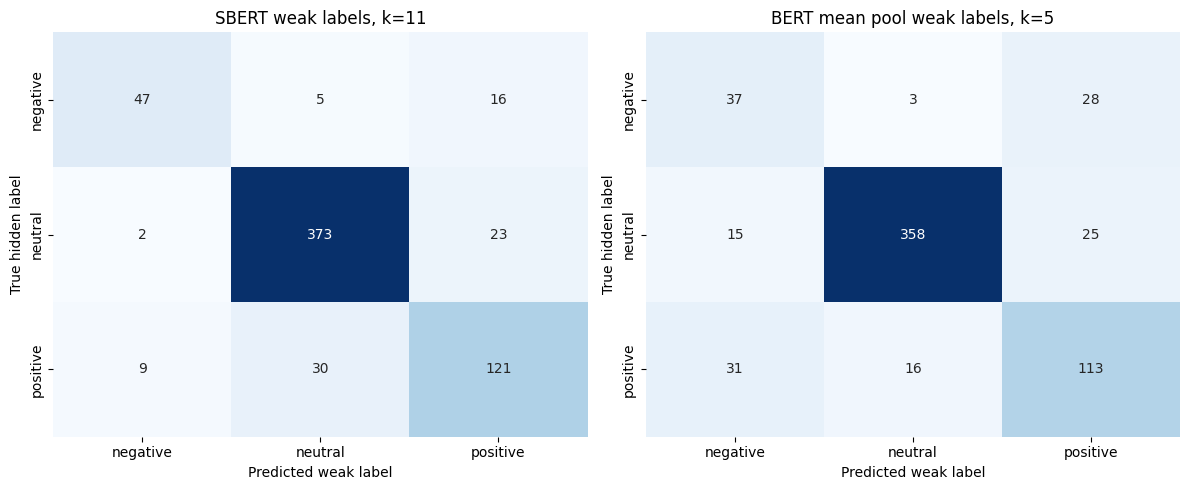

Best weak-label configuration:
{'embedding_name': 'SBERT', 'k': 11, 'seed_size': 1000, 'accuracy': 0.8642172523961661, 'macro_f1': 0.8092800195622777, 'negative_precision': 0.8103448275862069, 'negative_recall': 0.6911764705882353, 'negative_f1': 0.746031746031746, 'mean_vote_confidence': 0.7888469358117921}
Combined seed + weak-label rows: 1626


In [18]:
ranking_columns = ["negative_f1", "macro_f1", "accuracy", "k"]
ranking_order = [False, False, False, True]

best_sbert_row = (
    weak_label_results_df[weak_label_results_df["embedding_name"] == "SBERT"]
    .sort_values(ranking_columns, ascending=ranking_order)
    .iloc[0]
)
best_bert_row = (
    weak_label_results_df[weak_label_results_df["embedding_name"] == "BERT mean pool"]
    .sort_values(ranking_columns, ascending=ranking_order)
    .iloc[0]
)
best_overall_row = (
    weak_label_results_df
    .sort_values(ranking_columns, ascending=ranking_order)
    .iloc[0]
)

best_embedding_name = best_overall_row["embedding_name"]
best_k = int(best_overall_row["k"])
best_setting_key = f"{best_embedding_name} | k={best_k}"
best_weak_labels = weak_label_predictions[best_setting_key]["predicted_labels"]
best_weak_label_results = best_overall_row.to_dict()
best_weak_labeled_hidden_df = weak_label_predictions[best_setting_key][
    "weak_labeled_hidden_df"
].copy()

weak_label_seed_for_next_step_df = weak_label_seed_df[["sentence", "label"]].copy()
weak_label_seed_for_next_step_df["true_label"] = weak_label_seed_for_next_step_df["label"]
weak_label_seed_for_next_step_df["weak_label"] = weak_label_seed_for_next_step_df["label"]
weak_label_seed_for_next_step_df["weak_label_confidence"] = 1.0
weak_label_seed_for_next_step_df["embedding_name"] = "hard_label_seed"
weak_label_seed_for_next_step_df["k"] = np.nan
weak_label_seed_for_next_step_df["is_weak"] = False
weak_label_seed_for_next_step_df["prediction_correct"] = True

best_combined_train_with_weak_labels_df = pd.concat(
    [
        weak_label_seed_for_next_step_df,
        best_weak_labeled_hidden_df[
            [
                "sentence",
                "label",
                "true_label",
                "weak_label",
                "weak_label_confidence",
                "embedding_name",
                "k",
                "is_weak",
                "prediction_correct",
            ]
        ],
    ],
    ignore_index=True,
)

best_settings_df = pd.DataFrame(
    [best_sbert_row.to_dict(), best_bert_row.to_dict(), best_overall_row.to_dict()]
)
best_settings_df.index = ["best_sbert", "best_bert", "best_overall"]
display(best_settings_df)

best_setting_rows = [best_sbert_row, best_bert_row]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, best_row in zip(axes, best_setting_rows):
    setting_key = f"{best_row['embedding_name']} | k={int(best_row['k'])}"
    confusion = weak_label_confusion_matrices[setting_key]
    label_order = confusion["label_order"]
    label_names = [SENTIMENT_ID2LABEL[label_id] for label_id in label_order]
    confusion_df = pd.DataFrame(
        confusion["matrix"],
        index=label_names,
        columns=label_names,
    )

    sns.heatmap(
        confusion_df,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
    )
    ax.set_title(f"{best_row['embedding_name']} weak labels, k={int(best_row['k'])}")
    ax.set_xlabel("Predicted weak label")
    ax.set_ylabel("True hidden label")

plt.tight_layout()
plt.show()

print("Best weak-label configuration:")
print(best_weak_label_results)
print(f"Combined seed + weak-label rows: {len(best_combined_train_with_weak_labels_df)}")


## Weak Labeling Interpretation

Use the result table and confusion matrices above to answer three practical questions:
- whether SBERT produces better weak labels than plain BERT mean pooling
- which `k` gives the best trade-off between negative-class performance and overall stability
- whether the best weak labels look strong enough to justify semi-supervised retraining

The winning setting is stored in `best_embedding_name` and `best_k` and reused unchanged in the next section.

## Weak Labeling Summary

What this section contributes:
- direct weak-label evaluation on `hidden_allagree_pool`
- an embedding comparison between SBERT and plain BERT mean pooling
- selection of one best weak-labeling configuration for the downstream semi-supervised experiments

Prepared variables for reuse:
- `best_embedding_name`
- `best_k`
- `best_weak_labels`
- `best_weak_label_results`
- `best_weak_labeled_hidden_df`
- `best_combined_train_with_weak_labels_df`

The next section keeps that configuration fixed and asks whether adding these weak labels actually improves classifier training.

# Semi-Supervised Retraining

The next step keeps one classifier backbone fixed and compares hard-only training against hard-plus-weak training across all available clean seed sizes. This makes it possible to check whether weak labels improve performance or label efficiency, rather than just whether they look reasonable in isolation.

## Select the Classifier Backbone

We keep using one classifier backbone for the semi-supervised experiments. The selection rule stays simple: choose the backbone with the best `negative_f1` on `val_allagree` at the largest clean train size, then reuse that same backbone for every train-size comparison below.


In [19]:
semisup_backbone_selection_size = max(train_sizes)

semisup_backbone_candidates_df = baseline_results_df[
    (baseline_results_df["evaluation_split"] == "val_allagree")
    & (baseline_results_df["train_size"] == semisup_backbone_selection_size)
].copy()

selected_backbone_row = (
    semisup_backbone_candidates_df
    .sort_values(["negative_f1", "macro_f1", "model_key"], ascending=[False, False, True])
    .iloc[0]
)
selected_backbone_key = selected_backbone_row["model_key"]
selected_backbone_name = selected_backbone_row["model_name"]

selected_backbone_df = pd.DataFrame([selected_backbone_row.to_dict()])
display(selected_backbone_df)

print("Selected backbone key:", selected_backbone_key)
print("Selected backbone model:", selected_backbone_name)


,model_key,model_name,train_size,evaluation_split,negative_f1,accuracy,macro_f1,negative_precision,negative_recall
0,modernbert,answerdotai/ModernBERT-base,1000,val_allagree,0.96,0.939227,0.932799,0.923077,1.0


Selected backbone key: modernbert
Selected backbone model: answerdotai/ModernBERT-base


In [20]:
semisup_eval_splits = {
    "val_allagree": val_allagree_df,
    "test_allagree": test_allagree_df,
    "test_disagree": test_disagree_df,
}

if best_embedding_name == "SBERT":
    semisup_seed_embeddings_by_size = sbert_train_embeddings_by_size
    semisup_hidden_embeddings = sbert_hidden_embeddings
elif best_embedding_name == "BERT mean pool":
    semisup_seed_embeddings_by_size = bert_train_embeddings_by_size
    semisup_hidden_embeddings = bert_hidden_embeddings
else:
    raise ValueError(f"Unsupported best_embedding_name: {best_embedding_name}")


def train_and_evaluate_semisup_run(run_name, train_df, seed_size, output_dir):
    """Train one run and evaluate it on the fixed validation and test splits."""
    classifier = SentimentClassifier(
        model_name=selected_backbone_name,
        num_labels=len(SENTIMENT_ID2LABEL),
    )
    classifier.set_label_mapping(SENTIMENT_ID2LABEL, SENTIMENT_LABEL2ID)

    train_dataset = prepare_text_dataset(train_df, classifier.tokenizer)
    val_dataset = prepare_text_dataset(val_allagree_df, classifier.tokenizer)
    data_collator = DataCollatorWithPadding(tokenizer=classifier.tokenizer)

    trainer = Trainer(
        model=classifier.model,
        args=create_training_args(
            output_dir=output_dir,
            batch_size=16,
            epochs=3,
            seed=42,
        ),
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=data_collator,
        compute_metrics=lambda eval_pred: compute_metrics(
            eval_pred,
            negative_label=NEGATIVE_LABEL,
        ),
    )
    trainer.train()

    run_results = []
    for evaluation_split_name, evaluation_split_df in semisup_eval_splits.items():
        evaluation_dataset = prepare_text_dataset(
            evaluation_split_df,
            classifier.tokenizer,
        )
        evaluation_predictions = trainer.predict(evaluation_dataset)
        evaluation_metrics = compute_metrics(
            (evaluation_predictions.predictions, evaluation_predictions.label_ids),
            negative_label=NEGATIVE_LABEL,
        )

        run_results.append(
            {
                "run_type": run_name,
                "backbone_key": selected_backbone_key,
                "backbone_name": selected_backbone_name,
                "train_size": seed_size,
                "evaluation_split": evaluation_split_name,
                **evaluation_metrics,
            }
        )

    return run_results


In [ ]:
semisup_results = []
semisup_results_by_size = {}

for semisup_train_size in train_sizes:
    print(f"\n=== Semi-supervised comparison for train_{semisup_train_size} ===")

    current_seed_df = splits[f"train_{semisup_train_size}"][["sentence", "label"]].copy()
    current_seed_labels = train_labels_by_size[semisup_train_size]
    current_seed_embeddings = semisup_seed_embeddings_by_size[semisup_train_size]

    current_weak_labels, current_neighbor_indices, current_neighbor_distances, current_confidence_scores = (
        predict_knn_majority_vote(
            train_embeddings=current_seed_embeddings,
            train_labels=current_seed_labels,
            query_embeddings=semisup_hidden_embeddings,
            k=best_k,
        )
    )

    current_weak_hidden_df = hidden_allagree_pool.copy()
    current_weak_hidden_df["true_label"] = hidden_allagree_pool["label"].to_numpy()
    current_weak_hidden_df["label"] = current_weak_labels
    current_weak_hidden_df["weak_label"] = current_weak_labels
    current_weak_hidden_df["weak_label_confidence"] = current_confidence_scores
    current_weak_hidden_df["embedding_name"] = best_embedding_name
    current_weak_hidden_df["k"] = best_k
    current_weak_hidden_df["is_weak"] = True

    current_combined_train_df = pd.concat(
        [
            current_seed_df,
            current_weak_hidden_df[["sentence", "label"]],
        ],
        ignore_index=True,
    )

    current_baseline_results = train_and_evaluate_semisup_run(
        run_name="baseline_hard_only",
        train_df=current_seed_df,
        seed_size=semisup_train_size,
        output_dir=(
            f"models/semisup_curve_baseline_{selected_backbone_key}_{semisup_train_size}"
        ),
    )
    current_semisup_results = train_and_evaluate_semisup_run(
        run_name="semi_supervised_hard_plus_weak",
        train_df=current_combined_train_df,
        seed_size=semisup_train_size,
        output_dir=(
            f"models/semisup_curve_weak_{selected_backbone_key}_{semisup_train_size}"
        ),
    )

    semisup_results.extend(current_baseline_results)
    semisup_results.extend(current_semisup_results)
    semisup_results_by_size[semisup_train_size] = {
        "baseline_results": current_baseline_results,
        "semisup_results": current_semisup_results,
        "weak_labels": current_weak_labels,
        "weak_label_confidence": current_confidence_scores,
        "weak_hidden_df": current_weak_hidden_df,
        "combined_train_df": current_combined_train_df,
    }



=== Semi-supervised comparison for train_100 ===


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/181 [00:00<?, ? examples/s]

{'eval_loss': '0.7111', 'eval_accuracy': '0.663', 'eval_macro_f1': '0.4067', 'eval_negative_precision': '0.6', 'eval_negative_recall': '0.125', 'eval_negative_f1': '0.2069', 'eval_runtime': '0.7349', 'eval_samples_per_second': '246.3', 'eval_steps_per_second': '16.33', 'epoch': '1'}


...

{'loss': '0.785', 'grad_norm': '15.77', 'learning_rate': '1.941e-05', 'epoch': '0.09804'}
{'loss': '0.6062', 'grad_norm': '38.78', 'learning_rate': '1.876e-05', 'epoch': '0.1961'}
{'loss': '0.5107', 'grad_norm': '5.193', 'learning_rate': '1.81e-05', 'epoch': '0.2941'}
{'loss': '0.5368', 'grad_norm': '3.672', 'learning_rate': '1.745e-05', 'epoch': '0.3922'}
{'loss': '0.4151', 'grad_norm': '9.553', 'learning_rate': '1.68e-05', 'epoch': '0.4902'}
{'loss': '0.555', 'grad_norm': '17.69', 'learning_rate': '1.614e-05', 'epoch': '0.5882'}
{'loss': '0.4659', 'grad_norm': '10.31', 'learning_rate': '1.549e-05', 'epoch': '0.6863'}
{'loss': '0.4702', 'grad_norm': '4.728', 'learning_rate': '1.484e-05', 'epoch': '0.7843'}
{'loss': '0.2455', 'grad_norm': '7.05', 'learning_rate': '1.418e-05', 'epoch': '0.8824'}
{'loss': '0.2643', 'grad_norm': '11.12', 'learning_rate': '1.353e-05', 'epoch': '0.9804'}
{'eval_loss': '0.4013', 'eval_accuracy': '0.884', 'eval_macro_f1': '0.8458', 'eval_negative_precision': 

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.3074', 'grad_norm': '4.359', 'learning_rate': '1.288e-05', 'epoch': '1.078'}
{'loss': '0.3741', 'grad_norm': '7.581', 'learning_rate': '1.222e-05', 'epoch': '1.176'}
{'loss': '0.196', 'grad_norm': '3.699', 'learning_rate': '1.157e-05', 'epoch': '1.275'}
{'loss': '0.1653', 'grad_norm': '8.371', 'learning_rate': '1.092e-05', 'epoch': '1.373'}
{'loss': '0.1709', 'grad_norm': '6.878', 'learning_rate': '1.026e-05', 'epoch': '1.471'}
{'loss': '0.1766', 'grad_norm': '8.671', 'learning_rate': '9.608e-06', 'epoch': '1.569'}
{'loss': '0.1809', 'grad_norm': '3.476', 'learning_rate': '8.954e-06', 'epoch': '1.667'}
{'loss': '0.145', 'grad_norm': '5.1', 'learning_rate': '8.301e-06', 'epoch': '1.765'}
{'loss': '0.254', 'grad_norm': '5.301', 'learning_rate': '7.647e-06', 'epoch': '1.863'}
{'loss': '0.141', 'grad_norm': '14.14', 'learning_rate': '6.993e-06', 'epoch': '1.961'}
{'eval_loss': '0.1863', 'eval_accuracy': '0.9392', 'eval_macro_f1': '0.9255', 'eval_negative_precision': '0.8889', '

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.1926', 'grad_norm': '3.738', 'learning_rate': '6.34e-06', 'epoch': '2.059'}


In [ ]:
semisup_learning_curve_df = pd.DataFrame(semisup_results)
semisup_learning_curve_df = semisup_learning_curve_df[
    [
        "run_type",
        "backbone_key",
        "backbone_name",
        "train_size",
        "evaluation_split",
        "accuracy",
        "macro_f1",
        "negative_precision",
        "negative_recall",
        "negative_f1",
    ]
].sort_values(
    ["evaluation_split", "train_size", "run_type"],
    ascending=[True, True, True],
).reset_index(drop=True)

semisup_comparison_df = semisup_learning_curve_df.copy()
semisup_baseline_results = semisup_comparison_df[
    semisup_comparison_df["run_type"] == "baseline_hard_only"
].to_dict("records")
semisup_weak_results = semisup_comparison_df[
    semisup_comparison_df["run_type"] == "semi_supervised_hard_plus_weak"
].to_dict("records")

semisup_metric_columns = [
    "accuracy",
    "macro_f1",
    "negative_precision",
    "negative_recall",
    "negative_f1",
]

display(
    semisup_learning_curve_df.style.format(
        {column: "{:.4f}" for column in semisup_metric_columns}
    ).background_gradient(
        subset=["negative_f1"],
        cmap="YlGn",
    )
)


In [ ]:
plot_splits = [
    ("test_allagree", "Negative F1 vs Train Size on test_allagree"),
    ("test_disagree", "Negative F1 vs Train Size on test_disagree"),
]

for evaluation_split_name, plot_title in plot_splits:
    plot_df = semisup_learning_curve_df[
        semisup_learning_curve_df["evaluation_split"] == evaluation_split_name
    ]

    plt.figure(figsize=(10, 5))
    for run_type in ["baseline_hard_only", "semi_supervised_hard_plus_weak"]:
        run_df = plot_df[plot_df["run_type"] == run_type]
        plt.plot(
            run_df["train_size"],
            run_df["negative_f1"],
            marker="o",
            label=run_type,
        )

    plt.title(plot_title)
    plt.xlabel("Train size")
    plt.ylabel("Negative F1")
    plt.xticks(train_sizes)
    plt.legend()
    plt.grid(True)
    plt.show()

# Optional extra curve: keep only if it stays readable after execution.
macro_plot_df = semisup_learning_curve_df[
    semisup_learning_curve_df["evaluation_split"] == "test_allagree"
]

plt.figure(figsize=(10, 5))
for run_type in ["baseline_hard_only", "semi_supervised_hard_plus_weak"]:
    run_df = macro_plot_df[macro_plot_df["run_type"] == run_type]
    plt.plot(
        run_df["train_size"],
        run_df["macro_f1"],
        marker="o",
        label=run_type,
    )

plt.title("Macro F1 vs Train Size on test_allagree")
plt.xlabel("Train size")
plt.ylabel("Macro F1")
plt.xticks(train_sizes)
plt.legend()
plt.grid(True)
plt.show()


## Semi-Supervised Interpretation

The learning curves above compare hard-only training against hard-plus-weak training with the same backbone, evaluation splits, and train sizes.

Focus on three questions:
- does semi-supervised retraining improve `negative_f1`, especially at smaller train sizes
- do any gains carry over to `test_disagree`, not only `test_allagree`
- are the gains large enough to matter for the later time-savings estimate

This section is the direct test of whether weak labeling helps beyond the baseline comparison.

## Semi-Supervised Summary

What this section contributes:
- a fixed-backbone comparison between hard-only and hard-plus-weak training
- learning curves across `train_100`, `train_250`, `train_500`, and `train_1000`
- one consistent semi-supervised setup that can be reused for time-savings and agreement analysis

Prepared variables for the next sections:
- `semisup_learning_curve_df`
- `semisup_results_by_size`
- `selected_backbone_name`

The next section translates these learning-curve results into a cautious manual-label savings estimate.

# Time-Savings Estimate

This section uses the observed learning curves to estimate how many manual labels the semi-supervised setup might save. The main reference metric is `negative_f1` on `test_allagree`.

This addresses the assignment requirement to estimate manual-label savings from weak labeling / semi-supervised learning.

Read this estimate together with the agreement-level seed comparison below, because seed-label quality can affect the practical savings.

In [ ]:
time_savings_eval_splits = ["test_allagree", "test_disagree"]

baseline_curve_for_savings_df = baseline_results_df[
    (baseline_results_df["model_key"] == selected_backbone_key)
    & (baseline_results_df["evaluation_split"].isin(time_savings_eval_splits))
][["train_size", "evaluation_split", "negative_f1"]].copy()

semisup_curve_for_savings_df = semisup_learning_curve_df[
    (semisup_learning_curve_df["run_type"] == "semi_supervised_hard_plus_weak")
    & (semisup_learning_curve_df["evaluation_split"].isin(time_savings_eval_splits))
][["train_size", "evaluation_split", "negative_f1"]].copy()

time_savings_rows = []

for evaluation_split_name in time_savings_eval_splits:
    baseline_split_df = baseline_curve_for_savings_df[
        baseline_curve_for_savings_df["evaluation_split"] == evaluation_split_name
    ].sort_values("train_size")
    semisup_split_df = semisup_curve_for_savings_df[
        semisup_curve_for_savings_df["evaluation_split"] == evaluation_split_name
    ].sort_values("train_size")

    for _, semisup_row in semisup_split_df.iterrows():
        target_negative_f1 = semisup_row["negative_f1"]
        matching_baseline_df = baseline_split_df[
            baseline_split_df["negative_f1"] >= target_negative_f1
        ]

        if matching_baseline_df.empty:
            matched_baseline_train_size = np.nan
            absolute_labels_saved = np.nan
            relative_labels_saved_pct = np.nan
            match_status = "no observed baseline match"
        else:
            matched_baseline_train_size = int(
                matching_baseline_df.iloc[0]["train_size"]
            )
            absolute_labels_saved = (
                matched_baseline_train_size - int(semisup_row["train_size"])
            )
            relative_labels_saved_pct = (
                100 * absolute_labels_saved / matched_baseline_train_size
            )
            match_status = "matched on observed baseline sizes"

        time_savings_rows.append(
            {
                "eval_split": evaluation_split_name,
                "semi_supervised_train_size": int(semisup_row["train_size"]),
                "semi_supervised_negative_f1": target_negative_f1,
                "matched_baseline_train_size": matched_baseline_train_size,
                "absolute_labels_saved": absolute_labels_saved,
                "relative_labels_saved_pct": relative_labels_saved_pct,
                "match_status": match_status,
            }
        )

time_savings_df = pd.DataFrame(time_savings_rows)
primary_time_savings_df = time_savings_df[
    time_savings_df["eval_split"] == "test_allagree"
].reset_index(drop=True)
secondary_time_savings_df = time_savings_df[
    time_savings_df["eval_split"] == "test_disagree"
].reset_index(drop=True)

display(
    time_savings_df.style.format(
        {
            "semi_supervised_negative_f1": "{:.4f}",
            "relative_labels_saved_pct": "{:.1f}",
        },
        na_rep="not reached",
    ).background_gradient(
        subset=["absolute_labels_saved"],
        cmap="YlGn",
    )
)


In [ ]:
time_savings_plot_df = primary_time_savings_df.copy()

plt.figure(figsize=(10, 5))
bars = plt.bar(
    time_savings_plot_df["semi_supervised_train_size"].astype(str),
    time_savings_plot_df["absolute_labels_saved"].fillna(0),
    color="#4c72b0",
)

for bar, (_, row) in zip(bars, time_savings_plot_df.iterrows()):
    if pd.notna(row["matched_baseline_train_size"]):
        label_text = f"match {int(row['matched_baseline_train_size'])}"
        y_value = row["absolute_labels_saved"]
    else:
        label_text = "no match"
        y_value = 0

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        y_value + 5,
        label_text,
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.axhline(0, color="black", linewidth=1)
plt.title("Estimated Manual Labels Saved on test_allagree")
plt.xlabel("Semi-supervised hard-label train size")
plt.ylabel("Absolute labels saved vs matched baseline")
plt.grid(axis="y", alpha=0.3)
plt.show()


## Time-Savings Interpretation

This estimate is a proxy for manual-label savings: how many hard labels the semi-supervised setup might avoid while still reaching a similar `negative_f1` to the hard-only baseline.

The estimate is intentionally conservative:
- it uses only the observed train sizes already run in the notebook
- it does not interpolate between train sizes
- if no observed hard-only baseline point reaches the same score, the table records that explicitly instead of forcing a match

Read this as directional evidence about labeling efficiency, not as an exact cost calculation.

## Time-Savings Summary

What this section contributes:
- a simple observed-size matching rule between the semi-supervised curve and the hard-only baseline
- absolute and relative manual-label savings estimates where an observed match exists
- one compact visualization for the primary `test_allagree` view

This estimate becomes more informative when it is read together with the agreement-level comparison below.

# Agreement-Level Comparison

The final experiment block addresses the assignment question about annotator agreement. It compares a clean 100%-agreement seed set against a matched-size lower-agreement seed set while keeping the hidden pool, embedding family, `k`, and classifier backbone fixed.

In [ ]:
AGREEMENT_COMPARISON_SIZE = max(train_sizes)

agreement_high_seed_df = splits[f"train_{AGREEMENT_COMPARISON_SIZE}"][["sentence", "label"]].copy()
agreement_lower_seed_df, _ = train_test_split(
    splits["combined_non100_pool"][["sentence", "label"]].copy(),
    train_size=AGREEMENT_COMPARISON_SIZE,
    random_state=42,
    stratify=splits["combined_non100_pool"]["label"],
)
agreement_lower_seed_df = agreement_lower_seed_df.reset_index(drop=True)

agreement_hidden_df = hidden_allagree_pool.copy()
agreement_hidden_true_labels = agreement_hidden_df["label"].to_numpy()

if best_embedding_name == "SBERT":
    agreement_high_seed_embeddings = sbert_train_embeddings_by_size[AGREEMENT_COMPARISON_SIZE]
    agreement_lower_seed_embeddings = sbert_model.encode(
        agreement_lower_seed_df["sentence"].tolist(),
        batch_size=EMBEDDING_BATCH_SIZE,
        show_progress_bar=True,
    )
    agreement_hidden_embeddings = sbert_hidden_embeddings
elif best_embedding_name == "BERT mean pool":
    agreement_high_seed_embeddings = bert_train_embeddings_by_size[AGREEMENT_COMPARISON_SIZE]
    agreement_lower_seed_embeddings = encode_with_plain_bert(
        agreement_lower_seed_df["sentence"].tolist()
    )
    agreement_hidden_embeddings = bert_hidden_embeddings
else:
    raise ValueError(f"Unsupported best_embedding_name: {best_embedding_name}")

agreement_seed_overview_df = pd.concat(
    [
        agreement_high_seed_df["label"].value_counts().sort_index().rename("high_agreement_seed"),
        agreement_lower_seed_df["label"].value_counts().sort_index().rename("lower_agreement_seed"),
    ],
    axis=1,
).fillna(0).astype(int)
agreement_seed_overview_df.index = agreement_seed_overview_df.index.map(SENTIMENT_ID2LABEL)
display(agreement_seed_overview_df)


In [ ]:
agreement_seed_conditions = {
    "high_agreement_seed": {
        "seed_df": agreement_high_seed_df,
        "seed_labels": agreement_high_seed_df["label"].to_numpy(),
        "seed_embeddings": agreement_high_seed_embeddings,
    },
    "lower_agreement_seed": {
        "seed_df": agreement_lower_seed_df,
        "seed_labels": agreement_lower_seed_df["label"].to_numpy(),
        "seed_embeddings": agreement_lower_seed_embeddings,
    },
}

agreement_weak_label_results = []
agreement_weak_label_outputs = {}

for seed_condition, seed_values in agreement_seed_conditions.items():
    predicted_labels, neighbor_indices, neighbor_distances, confidence_scores = (
        predict_knn_majority_vote(
            train_embeddings=seed_values["seed_embeddings"],
            train_labels=seed_values["seed_labels"],
            query_embeddings=agreement_hidden_embeddings,
            k=best_k,
        )
    )

    predicted_logits = np.eye(len(SENTIMENT_ID2LABEL))[predicted_labels]
    metrics = compute_metrics(
        (predicted_logits, agreement_hidden_true_labels),
        negative_label=NEGATIVE_LABEL,
    )

    weak_hidden_df = agreement_hidden_df.copy()
    weak_hidden_df["true_label"] = agreement_hidden_true_labels
    weak_hidden_df["label"] = predicted_labels
    weak_hidden_df["weak_label"] = predicted_labels
    weak_hidden_df["weak_label_confidence"] = confidence_scores
    weak_hidden_df["seed_condition"] = seed_condition
    weak_hidden_df["embedding_name"] = best_embedding_name
    weak_hidden_df["k"] = best_k
    weak_hidden_df["is_weak"] = True

    agreement_weak_label_results.append(
        {
            "seed_condition": seed_condition,
            "seed_size": AGREEMENT_COMPARISON_SIZE,
            "embedding_name": best_embedding_name,
            "k": best_k,
            **metrics,
            "mean_vote_confidence": confidence_scores.mean(),
        }
    )
    agreement_weak_label_outputs[seed_condition] = {
        "predicted_labels": predicted_labels,
        "neighbor_indices": neighbor_indices,
        "neighbor_distances": neighbor_distances,
        "confidence_scores": confidence_scores,
        "weak_hidden_df": weak_hidden_df,
    }

agreement_weak_label_df = pd.DataFrame(agreement_weak_label_results)
agreement_weak_label_df = agreement_weak_label_df[
    [
        "seed_condition",
        "seed_size",
        "embedding_name",
        "k",
        "accuracy",
        "macro_f1",
        "negative_precision",
        "negative_recall",
        "negative_f1",
        "mean_vote_confidence",
    ]
].sort_values("seed_condition").reset_index(drop=True)

display(
    agreement_weak_label_df.style.format(
        {
            "accuracy": "{:.4f}",
            "macro_f1": "{:.4f}",
            "negative_precision": "{:.4f}",
            "negative_recall": "{:.4f}",
            "negative_f1": "{:.4f}",
            "mean_vote_confidence": "{:.3f}",
        }
    ).background_gradient(
        subset=["negative_f1"],
        cmap="YlGn",
    )
)


In [ ]:
agreement_high_combined_train_df = pd.concat(
    [
        agreement_high_seed_df,
        agreement_weak_label_outputs["high_agreement_seed"]["weak_hidden_df"][["sentence", "label"]],
    ],
    ignore_index=True,
)
agreement_lower_combined_train_df = pd.concat(
    [
        agreement_lower_seed_df,
        agreement_weak_label_outputs["lower_agreement_seed"]["weak_hidden_df"][["sentence", "label"]],
    ],
    ignore_index=True,
)

agreement_baseline_high_results = train_and_evaluate_semisup_run(
    run_name="baseline_high_agreement_hard_only",
    train_df=agreement_high_seed_df,
    seed_size=AGREEMENT_COMPARISON_SIZE,
    output_dir=(
        f"models/agreement_baseline_high_{selected_backbone_key}_{AGREEMENT_COMPARISON_SIZE}"
    ),
)
agreement_semisup_high_results = train_and_evaluate_semisup_run(
    run_name="semi_supervised_high_agreement_seed",
    train_df=agreement_high_combined_train_df,
    seed_size=AGREEMENT_COMPARISON_SIZE,
    output_dir=(
        f"models/agreement_semisup_high_{selected_backbone_key}_{AGREEMENT_COMPARISON_SIZE}"
    ),
)
agreement_semisup_lower_results = train_and_evaluate_semisup_run(
    run_name="semi_supervised_lower_agreement_seed",
    train_df=agreement_lower_combined_train_df,
    seed_size=AGREEMENT_COMPARISON_SIZE,
    output_dir=(
        f"models/agreement_semisup_lower_{selected_backbone_key}_{AGREEMENT_COMPARISON_SIZE}"
    ),
)

agreement_downstream_results = (
    agreement_baseline_high_results
    + agreement_semisup_high_results
    + agreement_semisup_lower_results
)

agreement_downstream_df = pd.DataFrame(agreement_downstream_results)
agreement_downstream_df = agreement_downstream_df[
    [
        "run_type",
        "backbone_key",
        "backbone_name",
        "train_size",
        "evaluation_split",
        "accuracy",
        "macro_f1",
        "negative_precision",
        "negative_recall",
        "negative_f1",
    ]
].sort_values(["evaluation_split", "run_type"]).reset_index(drop=True)

display(
    agreement_downstream_df.style.format(
        {
            "accuracy": "{:.4f}",
            "macro_f1": "{:.4f}",
            "negative_precision": "{:.4f}",
            "negative_recall": "{:.4f}",
            "negative_f1": "{:.4f}",
        }
    ).background_gradient(
        subset=["negative_f1"],
        cmap="YlGn",
    )
)


In [ ]:
agreement_plot_df = agreement_downstream_df[
    agreement_downstream_df["evaluation_split"].isin(["test_allagree", "test_disagree"])
].copy()
agreement_plot_df["run_label"] = agreement_plot_df["run_type"].map(
    {
        "baseline_high_agreement_hard_only": "baseline high-agreement hard only",
        "semi_supervised_high_agreement_seed": "semi-supervised high-agreement seed",
        "semi_supervised_lower_agreement_seed": "semi-supervised lower-agreement seed",
    }
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=agreement_plot_df,
    x="evaluation_split",
    y="negative_f1",
    hue="run_label",
)
plt.title("Negative F1 by Seed-Agreement Condition")
plt.xlabel("Evaluation split")
plt.ylabel("Negative F1")
plt.legend(title="run")
plt.grid(axis="y", alpha=0.3)
plt.show()


## Agreement-Level Interpretation

This comparison isolates seed-label quality while keeping the rest of the weak-labeling pipeline fixed.

The key question is whether cleaner seed labels lead to:
- better direct weak labels on `hidden_allagree_pool`
- stronger downstream semi-supervised results on `val_allagree`, `test_allagree`, and `test_disagree`

Because the comparison is intentionally narrow, it should be read as focused evidence about this setup rather than as a universal rule.

## Agreement-Level Summary

What this section contributes:
- a matched comparison between high-agreement and lower-agreement seed labels
- direct weak-label quality results on the same hidden clean pool
- downstream classifier results with the same selected backbone and evaluation splits

Together with the earlier learning curves and time-savings estimate, this section closes the loop on the assignment's question about how much seed-label quality matters.

# How This Notebook Addresses the Assignment Requirements

This notebook covers the requested components directly and keeps the mapping explicit:
- **Number of manually labeled examples:** the nested seed sets `train_100`, `train_250`, `train_500`, and `train_1000` show how results change with 100, 250, 500, and 1000 manually labeled examples.
- **Annotator agreement level:** agreement is examined both through `test_allagree` versus `test_disagree` and through the matched `high_agreement_seed` versus `lower_agreement_seed` comparison.
- **Semi-supervised configuration:** the notebook fixes one selected classifier backbone together with `best_embedding_name` and `best_k`, then compares hard-only against hard-plus-weak retraining across train sizes.
- **Baseline model comparison:** `baseline_results_df` and the baseline plots compare DistilBERT and ModernBERT under the same data splits and training setup.
- **Embedding comparison:** `embedding_quality_df` and `weak_label_results_df` compare SBERT against plain BERT mean pooling for neighborhood quality and direct weak-label performance.
- **Weak labeling:** the k-NN section generates weak labels for `hidden_allagree_pool`, evaluates them against the hidden clean labels, and stores the selected setting for reuse.
- **Time-savings estimate:** `time_savings_df` translates the learning curves into a cautious estimate of possible manual-label savings on observed train sizes.

# Conclusion

The cell below turns the executed result tables into a short, presentation-ready summary of the main findings.

In [ ]:
baseline_choice_row = (
    baseline_results_df[
        (baseline_results_df["evaluation_split"] == "val_allagree")
        & (baseline_results_df["train_size"] == max(train_sizes))
    ]
    .sort_values(["negative_f1", "macro_f1", "model_key"], ascending=[False, False, True])
    .iloc[0]
)

best_test_baseline_row = (
    baseline_results_df[baseline_results_df["evaluation_split"] == "test_allagree"]
    .sort_values(["negative_f1", "macro_f1", "accuracy", "train_size"], ascending=[False, False, False, False])
    .iloc[0]
)

best_sbert_row = (
    weak_label_results_df[weak_label_results_df["embedding_name"] == "SBERT"]
    .sort_values(["negative_f1", "macro_f1", "accuracy", "k"], ascending=[False, False, False, True])
    .iloc[0]
)
best_bert_row = (
    weak_label_results_df[weak_label_results_df["embedding_name"] == "BERT mean pool"]
    .sort_values(["negative_f1", "macro_f1", "accuracy", "k"], ascending=[False, False, False, True])
    .iloc[0]
)

if best_sbert_row["negative_f1"] > best_bert_row["negative_f1"]:
    weak_label_comparison = (
        f"SBERT was stronger for weak labeling than plain BERT mean pooling "
        f"({best_sbert_row['negative_f1']:.3f} vs {best_bert_row['negative_f1']:.3f} best negative F1)."
    )
elif best_sbert_row["negative_f1"] < best_bert_row["negative_f1"]:
    weak_label_comparison = (
        f"Plain BERT mean pooling was stronger for weak labeling than SBERT "
        f"({best_bert_row['negative_f1']:.3f} vs {best_sbert_row['negative_f1']:.3f} best negative F1)."
    )
else:
    weak_label_comparison = (
        f"SBERT and plain BERT mean pooling tied on best weak-label negative F1 "
        f"({best_sbert_row['negative_f1']:.3f})."
    )

semisup_delta_df = (
    semisup_learning_curve_df
    .pivot_table(
        index=["train_size", "evaluation_split"],
        columns="run_type",
        values="negative_f1",
        aggfunc="first",
    )
    .reset_index()
)
semisup_delta_df["delta_negative_f1"] = (
    semisup_delta_df["semi_supervised_hard_plus_weak"]
    - semisup_delta_df["baseline_hard_only"]
)

allagree_improvements = semisup_delta_df[
    (semisup_delta_df["evaluation_split"] == "test_allagree")
    & (semisup_delta_df["delta_negative_f1"] > 0)
]
disagree_improvements = semisup_delta_df[
    (semisup_delta_df["evaluation_split"] == "test_disagree")
    & (semisup_delta_df["delta_negative_f1"] > 0)
]
best_semisup_gain_row = semisup_delta_df.sort_values("delta_negative_f1", ascending=False).iloc[0]

if best_semisup_gain_row["delta_negative_f1"] > 0:
    semisup_line = (
        f"Semi-supervised retraining improved negative F1 on "
        f"{len(allagree_improvements)}/{len(train_sizes)} observed train sizes for `test_allagree` "
        f"and {len(disagree_improvements)}/{len(train_sizes)} for `test_disagree`; "
        f"the largest gain was {best_semisup_gain_row['delta_negative_f1']:.3f} on "
        f"{best_semisup_gain_row['evaluation_split']} at train size {int(best_semisup_gain_row['train_size'])}."
    )
else:
    semisup_line = (
        "Semi-supervised retraining did not beat the hard-only baseline on the observed negative-F1 comparisons."
    )

agreement_compare_df = (
    agreement_downstream_df
    .pivot_table(
        index="evaluation_split",
        columns="run_type",
        values="negative_f1",
        aggfunc="first",
    )
    .reset_index()
)
agreement_compare_df["high_minus_lower"] = (
    agreement_compare_df["semi_supervised_high_agreement_seed"]
    - agreement_compare_df["semi_supervised_lower_agreement_seed"]
)

if (agreement_compare_df["high_minus_lower"] > 0).all():
    agreement_line = "Cleaner seed labels helped consistently: the high-agreement seed condition beat the lower-agreement seed condition on every evaluation split reported here."
elif (agreement_compare_df["high_minus_lower"] < 0).all():
    agreement_line = "The lower-agreement seed condition beat the high-agreement seed condition on every evaluation split reported here."
else:
    better_count = int((agreement_compare_df["high_minus_lower"] > 0).sum())
    agreement_line = (
        f"Cleaner seed labels helped, but not uniformly: the high-agreement seed condition was better on {better_count} of {len(agreement_compare_df)} evaluation splits."
    )

matched_savings_df = primary_time_savings_df.dropna(subset=["absolute_labels_saved"])
if matched_savings_df.empty:
    savings_line = "On the observed `test_allagree` train sizes, the semi-supervised curve did not yet produce a direct matched manual-label saving against the hard-only baseline."
else:
    best_savings_row = matched_savings_df.sort_values(
        ["absolute_labels_saved", "relative_labels_saved_pct"],
        ascending=[False, False],
    ).iloc[0]
    savings_line = (
        f"The time-savings estimate suggests that semi-supervised training can replace up to "
        f"{int(best_savings_row['absolute_labels_saved'])} observed manual labels "
        f"({best_savings_row['relative_labels_saved_pct']:.1f}%) at train size "
        f"{int(best_savings_row['semi_supervised_train_size'])} on `test_allagree`, "
        f"when a matched baseline point exists."
    )

final_conclusion_markdown = f"""
- **Best baseline model:** `{baseline_choice_row['model_key']}` was the selected backbone under the notebook's validation rule, and the best `test_allagree` baseline run reached a negative F1 of {best_test_baseline_row['negative_f1']:.3f} at train size {int(best_test_baseline_row['train_size'])}.
- **Best weak-labeling setup:** `{best_embedding_name}` with `k = {best_k}` gave the strongest direct weak-label result on `hidden_allagree_pool`. {weak_label_comparison}
- **Semi-supervised learning:** {semisup_line}
- **Annotator agreement:** {agreement_line}
- **Limitations:** the learning-curve and time-savings conclusions only use the observed train sizes, and the agreement comparison is a matched single-size study rather than a full sweep.
- **Time-savings estimate:** {savings_line}
"""

display(Markdown(final_conclusion_markdown))


## Limitations and Future Work

- The learning-curve and time-savings conclusions depend on the observed train sizes (`100`, `250`, `500`, `1000`) and do not interpolate beyond them.
- The agreement-level comparison uses one matched seed size to keep the notebook manageable, so it should be read as a focused case study.
- The notebook keeps the training and weak-labeling choices simple and does not perform an exhaustive hyperparameter search.
- Earlier bonus ideas such as UMAP visualization or prompt-based LLM classification were intentionally removed from the runnable submission path so the notebook remains focused and reproducible.

The final cell below lists the main result artifacts produced by the notebook and confirms the notebook is ready for review.

In [ ]:
final_artifacts_df = pd.DataFrame(
    [
        {
            "variable": "baseline_results_df",
            "description": "Baseline backbone comparison across train sizes and evaluation splits",
        },
        {
            "variable": "embedding_quality_df",
            "description": "Embedding-space diagnostics for SBERT versus plain BERT mean pooling",
        },
        {
            "variable": "weak_label_results_df",
            "description": "Direct weak-label performance for each embedding family and k",
        },
        {
            "variable": "best_embedding_name, best_k",
            "description": "Selected weak-labeling setup reused for semi-supervised training",
        },
        {
            "variable": "semisup_learning_curve_df",
            "description": "Hard-only versus hard-plus-weak learning-curve results",
        },
        {
            "variable": "time_savings_df",
            "description": "Observed manual-label savings estimate from the learning curves",
        },
        {
            "variable": "agreement_weak_label_df",
            "description": "Direct weak-label comparison for high-agreement versus lower-agreement seeds",
        },
        {
            "variable": "agreement_downstream_df",
            "description": "Downstream agreement-level comparison with the selected backbone",
        },
    ]
)

display(final_artifacts_df)
print("Notebook ready for a full top-to-bottom run and review once the training cells above are executed.")
